# Gaussian Process Regression: Airline Passengers Data Set

        Phy      NO2       NO3        NH4        PO4 Site       Bay  Depth
Chl_a                                                                     
6.66   0.74  0.21830  0.522735  31.784807  15.317651  XVI  West Bay  1.097
6.45   0.78  0.21830  0.522735  31.784807  15.317651  XVI  West Bay  1.098
6.27   0.77  0.21830  0.522735  31.784807  15.317651  XVI  West Bay  1.098
6.13   0.58  0.21495  0.527931  30.446107  14.834307  XVI  West Bay  2.004
6.10   0.57  0.21495  0.527931  30.446107  14.834307  XVI  West Bay  2.004


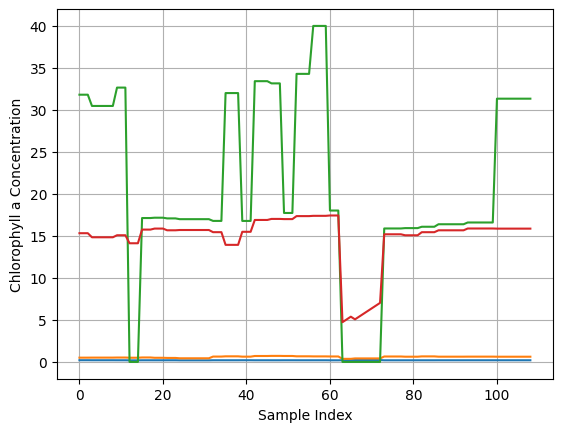

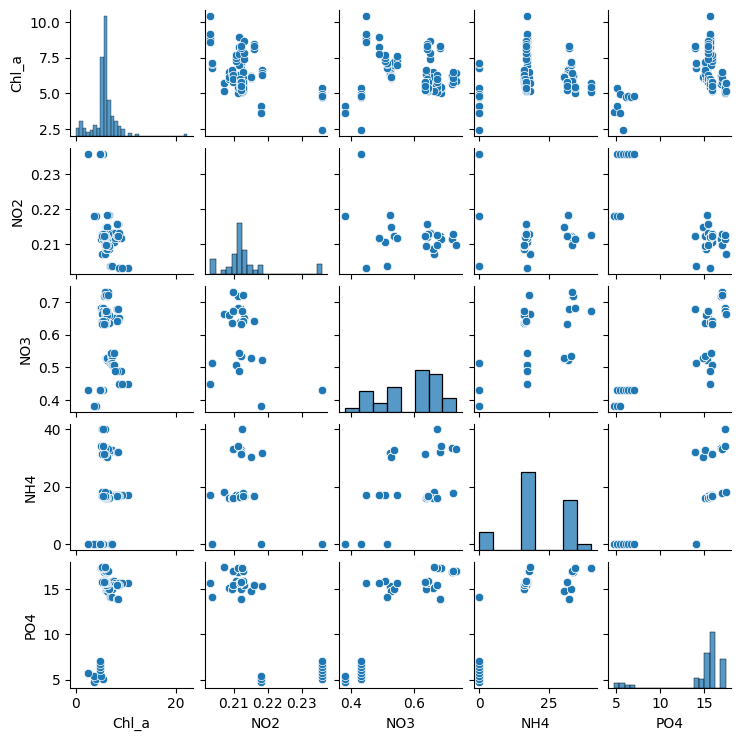

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import ExpSineSquared
from sklearn.gaussian_process.kernels import WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

url = 'https://raw.githubusercontent.com/kspilario/predict_chlorophyll/refs/heads/main/chlor.csv'
df = pd.read_csv(url, index_col=0)
print(df.head(5))
X = df[['NO2', 'NO3', 'NH4', 'PO4']].dropna() # we can change the imputation strategy here
y = X.index.values

plt.plot(np.arange(0,len(X)),X)
plt.grid()
plt.ylabel('Chlorophyll a Concentration')
plt.xlabel('Sample Index')
plt.show()

df_reset = df.reset_index()
# sns.pairplot(df_reset[['NO2', 'NO3', 'NH4', 'PO4', 'Chl_a']], hue='Chl_a', height=1.5)
sns.pairplot(df_reset[['Chl_a', 'NO2', 'NO3', 'NH4', 'PO4']], height=1.5)
plt.show()

Split the data into 70% training and 30% testing.

(76, 4) (33, 4) (76,) (33,)


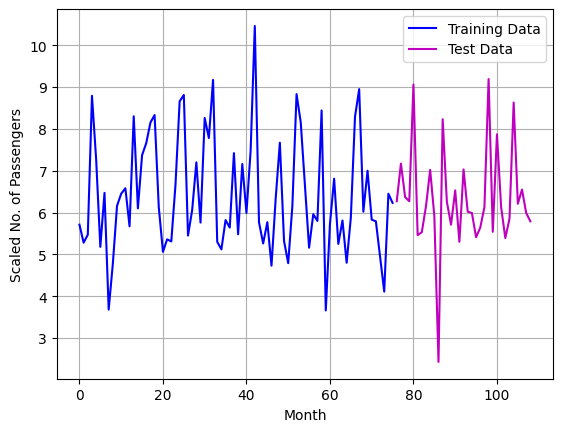

(76, 4)
(76, 1)
(33, 4)
(33, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# scaler = MinMaxScaler()
y_train_scaled = y_train.reshape(-1, 1)
y_test_scaled = y_test.reshape(-1, 1)

plt.plot(np.arange(0, len(y_train_scaled)), y_train_scaled.ravel(), 'b')
plt.plot(np.arange(len(y_train_scaled), len(y_train_scaled) + len(y_test_scaled)), y_test_scaled.ravel(), 'm')
plt.grid()
plt.legend(('Training Data', 'Test Data'))
plt.ylabel('Scaled No. of Passengers')
plt.xlabel('Month')
plt.show()
print(X_train.shape)
print(y_train_scaled.shape)
print(X_test.shape)
print(y_test_scaled.shape)

Define the kernel composition and fit using GPR.

In [7]:
SExPER_kernel = (RBF(length_scale=1.5) * ExpSineSquared(length_scale=0.5, periodicity=12))

noise_kernel = WhiteKernel(noise_level=0.01)

overall_kernel = (SExPER_kernel + noise_kernel)

y_mean = y_train_scaled.mean()

GPR = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=overall_kernel, 
                               normalize_y=False, 
                               n_restarts_optimizer=10,
                               random_state=0)).fit(X_train, y_train)
GPR.fit(X_train, y_train_scaled - y_mean)

,steps,"[('standardscaler', ...), ('gaussianprocessregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,RBF(length_sc...se_level=0.01)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10


Predict on test data and visualize results.

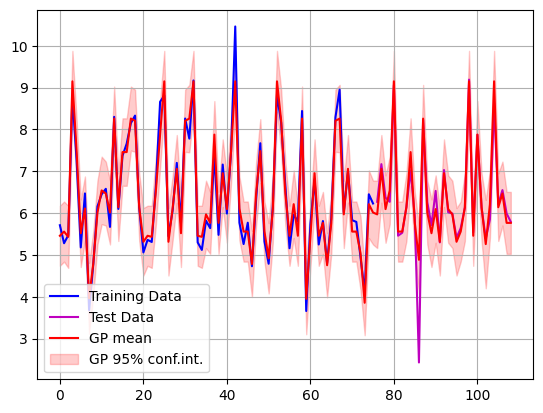

Optimized kernel:
RBF(length_scale=0.327) * ExpSineSquared(length_scale=1.49, periodicity=0.102) + WhiteKernel(noise_level=0.115)
Training MSE: 0.08086657423396781
Testing MSE: 0.22158130625826072


In [ ]:
# Use the original X data (features) for prediction
from sklearn.metrics import confusion_matrix


X_all = pd.concat([X_train, X_test])
train_size = len(X_train)
mean_y_pred, std_y_pred = GPR.predict(X_all, return_std=True)
mean_y_pred += y_mean
plt.plot(np.arange(0,len(y_train_scaled)), y_train_scaled,'b',label='Training Data')
plt.plot(np.arange(len(y_train_scaled), len(y_train_scaled) + len(y_test_scaled)), y_test_scaled, 'm', label='Test Data')
plt.plot(X,mean_y_pred,'r',label='GP mean')
plt.fill_between(
    X.ravel(),
    mean_y_pred - 1.96*std_y_pred,
    mean_y_pred + 1.96*std_y_pred,
    color='r',
    alpha=0.2,
    label='GP 95% conf.int.'
)
# plt.ylabel('Scaled No. of Passengers')
# plt.xlabel('Month')
plt.grid()
plt.legend()
plt.show()
print('Optimized kernel:')
print(GPR.named_steps['gaussianprocessregressor'].kernel_)
train_mse = mean_squared_error(y_train_scaled, mean_y_pred[:train_size])
test_mse = mean_squared_error(y_test_scaled, mean_y_pred[train_size:len(df)])
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")
from sklearn.metrics import r2_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
cfm = confusion_matrix(y_test, mean_y_pred[len(y_train):])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cfm)
cm_display.plot()
plt.title('Testing Data: Confusion Matrix')